**Preliminari**

In [54]:
import sys
import os
from dotenv import load_dotenv
from pathlib import Path

from BERT_utils import create_label_to_id_map, labels_to_bits, bits_to_labels, NAN_VALUE, get_multiple_choice_fields

# if notebook is in PRIN/notebooks, parent() is PRIN
#project_root = Path.cwd().resolve().parent
#sys.path.insert(0, str(project_root))
#print("Added to sys.path:", project_root)

import json
#from utils.schema_json import ReportData, AnnotatedReport
import time
from IPython.display import clear_output

from huggingface_hub import login

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from transformers import AutoTokenizer, DefaultDataCollator
from datasets import load_dataset, Dataset, DatasetDict

from constants import AnnotatedReport, Annotations

from classifiers import ReportExtractor
from tqdm import tqdm
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
from ast import literal_eval
import loop
import seaborn as sns
import matplotlib.pyplot as plt

**Impostiamo il device, scheda video se disponibile**

In [55]:
print(f'{torch.cuda.is_available() = }')  # True se la GPU è disponibile
print(f'{torch.cuda.device_count() = }')  # Numero di GPU disponibili
print(f'{torch.cuda.get_device_name(0) = }')  # Nome della GPU

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'{device = }')

torch.cuda.is_available() = True
torch.cuda.device_count() = 1
torch.cuda.get_device_name(0) = 'NVIDIA GeForce GTX 1060 6GB'
device = device(type='cuda')


**Huggingface login**

In [56]:
# Set the API key for HuggingFace
load_dotenv()  # Load environment variables from .env file
hf_api_key = os.getenv("HF_TOKEN")
login(token=hf_api_key)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


**Parametri**

In [57]:
# Parameters
TRAIN_FILE_NAME = "train_split.csv"
VALIDATION_FILE_NAME = "validation_split.csv"


CHECKPOINT = "bert-base-multilingual-cased"

**Load data**

In [58]:
# Carichiamo i nostri file JSON
file_names = {
    'train': TRAIN_FILE_NAME,
    'validation': VALIDATION_FILE_NAME,
}

paths = {
    split: Path('../data/' + file_name) for split, file_name in file_names.items()
}

data = dict()
for split, path in paths.items():
    with open(path, "r", encoding="utf-8") as f:
        data[split] = pd.read_csv(f)

train_data, validation_data = data['train'], data['validation']

print(f"{len(train_data) = }")
print(f"{len(validation_data) = }")

len(train_data) = 116
len(validation_data) = 28


In [59]:
annotated_reports: dict[str, list[AnnotatedReport]] = {split: [] for split in file_names.keys()}
mc_fields = get_multiple_choice_fields(Annotations)
for split in data:
    df = data[split].fillna(NAN_VALUE)
    for _, row in df.iterrows():
        annotations_dict = dict()
        for field in Annotations.model_fields.keys():
            v = row[field]
            if v == NAN_VALUE:
                v = None
            if field in mc_fields:
                v = literal_eval(v)
            annotations_dict[field] = v
        annotated_reports[split].append(AnnotatedReport(report_text=row['report_text'], report_data=annotations_dict))

**Load model and tokenizer**

In [60]:
model = ReportExtractor().to(device)
tokenizer = AutoTokenizer.from_pretrained(model.checkpoint)

In [61]:
# Check the maximum number of tokens for each report
max_n_tokens_train = 0
del_train = []
for i, report in enumerate(annotated_reports['train']):
    x = tokenizer(report.report_text, return_tensors='pt')['input_ids'].shape[1]
    max_n_tokens_train = max(max_n_tokens_train, x)
    if x > model.encoder.config.max_position_embeddings:
        del_train.append(i)
print(del_train)
print(f'{max_n_tokens_train = }')

# Check the maximum number of tokens for each report
max_n_tokens_validation = 0
del_val = []
for i, report in enumerate(annotated_reports['validation']):
    x = tokenizer(report.report_text, return_tensors='pt')['input_ids'].shape[1]
    max_n_tokens_validation = max(max_n_tokens_validation, x)
    if x > model.encoder.config.max_position_embeddings:
        del_val.append(i)
print(del_val)
print(f'{max_n_tokens_validation = }')

# Delete long reports
for i in del_train[::-1]:
    annotated_reports['train'].pop(i)
for i in del_val[::-1]:
    annotated_reports['validation'].pop(i)
print('deleted')

Token indices sequence length is longer than the specified maximum sequence length for this model (612 > 512). Running this sequence through the model will result in indexing errors


[1, 4, 5, 8, 10, 11, 13, 17, 21, 31, 36, 39, 45, 49, 50, 64, 66, 69, 73, 75, 77, 78, 84, 86, 88, 89, 94, 95, 97, 98, 100, 103, 111, 112, 114, 115]
max_n_tokens_train = 1211
[0, 1, 2, 5, 6, 8, 9, 12, 13, 15, 16, 17, 21, 23, 24, 26, 27]
max_n_tokens_validation = 1799
deleted


In [62]:
def create_hugging_face_dataset(annotated_reports: list[AnnotatedReport]) -> Dataset:
    text = []
    for report in annotated_reports:
        text.append(report.report_text)
    return Dataset.from_dict({'text': text})

In [63]:
dataset = DatasetDict({
    'train': create_hugging_face_dataset(annotated_reports['train']),
    'validation': create_hugging_face_dataset(annotated_reports['validation'])
})

In [64]:
def tokenize_function(examples):
    return tokenizer(examples['text'], padding="max_length", max_length=model.encoder.config.max_position_embeddings)

In [65]:
dataset = dataset.map(tokenize_function, batched=True)
dataset.set_format('torch')

Map:   0%|          | 0/80 [00:00<?, ? examples/s]

Map:   0%|          | 0/11 [00:00<?, ? examples/s]

In [66]:
dataset = dataset.remove_columns(["token_type_ids", "text"])

In [67]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 80
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 11
    })
})


In [68]:
label_to_id_map = create_label_to_id_map(model.annotations_model)

In [69]:
# Classification fields
for f in model.classification_fields:
    for split in ('train', 'validation'):
        target: list[int] = []
        for r in annotated_reports[split]:
            label = getattr(r.report_data, f)
            if label is None:
                label = NAN_VALUE
            id = label_to_id_map[f]['label_to_id'][label]
            target.append(id)
        dataset[split] = dataset[split].add_column(f, target)

In [70]:
# Regression fields
for f in model.regression_fields:
    for split in ('train', 'validation'):
        target: list[float] = []
        for r in annotated_reports[split]:
            value = getattr(r.report_data, f)
            if value is None:
                value = 0
            target.append(float(value))
        dataset[split] = dataset[split].add_column(f, target)

In [71]:
# Multiple choice fields
for f in model.multiple_choice_fields:
    for split in ('train', 'validation'):
        target: list[list[int]] = []
        for r in annotated_reports[split]:
            values = getattr(r.report_data, f)
            bits = labels_to_bits(values, label_to_id_map[f]['label_to_id'])
            target.append(bits)
        dataset[split] = dataset[split].add_column(f, target)

In [72]:
dataset

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'morfologia', 'riflessione_peritoneale_anteriore', 'infiltrazione_tessuto_adiposo', 'infiltrazione_sfinteri', 'infiltrazione_organi_extra', 'coinvolgimento_riflessione_peritoneale', 'coinvolgimento_fascia_mesorettale', 'numero_linfonodi_non_conosciuto', 'depositi_tumorali', 'emvi_esteso', 'stadio_T', 'stadio_N', 'stadio_N1c', 'mrf', 'emvi', 'metastasi', 'ore_inizio', 'ore_fine', 'spessore_parietale', 'estensione_cranio_caudale', 'distanza_oai', 'linfonodi_sospetti', 'numero_depositi', 'posizione', 'infiltrazione_organi_dettagli', 'sedi_linfonodi'],
        num_rows: 80
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'morfologia', 'riflessione_peritoneale_anteriore', 'infiltrazione_tessuto_adiposo', 'infiltrazione_sfinteri', 'infiltrazione_organi_extra', 'coinvolgimento_riflessione_peritoneale', 'coinvolgimento_fascia_mesorettale', 'numero_linfonodi_non_conosciuto', 'd

# Training with pure PyTorch

In [73]:
model = ReportExtractor().to(device)
tokenizer = AutoTokenizer.from_pretrained(model.checkpoint)

In [74]:
# Se voglio allenare solo le teste di classificazione
for param in model.encoder.parameters():
    param.requires_grad = False

In [75]:
# Parametri totali
total_params = sum(p.numel() for p in model.parameters())

# Parametri allenabili (quelli con gradiente)
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Parametri totali: {total_params:,}")
print(f"Parametri allenabili: {trainable_params:,}")

Parametri totali: 177,913,422
Parametri allenabili: 59,982


In [76]:
out_feat = 0
for head in model.heads.values():
    out_feat += head.out_features
print(f'Parametri delle teste di estrazione: {model.encoder.config.hidden_size * out_feat + out_feat}')

Parametri delle teste di estrazione: 59982


In [77]:
# Training parameters
n_epochs = 20
batch_size = 4
learning_rate = 2e-3

In [78]:
loss = loop.train(
    model,
    dataset_train=dataset['train'],
    dataset_validation=dataset['validation'],
    epochs=n_epochs,
    batch_size=batch_size,
    lr=learning_rate,
    verbose=1
)

100%|██████████| 20/20 [00:04<00:00,  4.84it/s]


Epoch 1/20 - Training loss: 195.9530
Validation loss: 123.8698


100%|██████████| 20/20 [00:04<00:00,  4.98it/s]


Epoch 2/20 - Training loss: 171.9043
Validation loss: 105.4416


100%|██████████| 20/20 [00:03<00:00,  5.06it/s]


...

Epoch 18/20 - Training loss: 63.8020
Validation loss: 44.6457


100%|██████████| 20/20 [00:03<00:00,  5.03it/s]


Epoch 19/20 - Training loss: 62.3136
Validation loss: 45.5265


100%|██████████| 20/20 [00:04<00:00,  5.00it/s]


Epoch 20/20 - Training loss: 64.3698
Validation loss: 45.0728


Text(0.5, 0, 'Epoch')

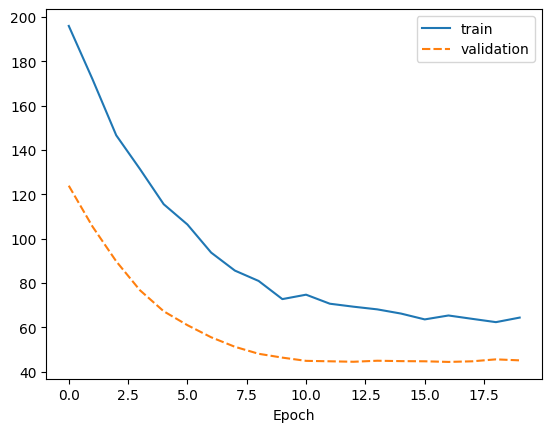

In [79]:
sns.lineplot(data=pd.DataFrame(loss))
plt.xlabel('Epoch')